# Basic EDA for SIP Reports

This notebook extracts text from SIP reports (with careful handling for different internal document structures) and performs basic exploratory data analysis.

## 1) Setup
If imports fail, run the install cell below once.

In [70]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from docx import Document
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 200)

In [71]:
# Run this once if you are missing packages:
# %pip install python-docx pandas matplotlib seaborn scikit-learn

## 2) Configure Folder Path

In [72]:
# If needed, update this path to your local workspace location.
REPORTS_DIR = Path(r"c:\\Users\\yunlin\\OneDrive - Temasek Polytechnic\\Documents\\SIP_Reports\\SIPReports_ToYunLin")

if not REPORTS_DIR.exists():
    raise FileNotFoundError(f'Reports folder not found: {REPORTS_DIR}')

files = sorted([p for p in REPORTS_DIR.iterdir() if p.is_file()])
print(f'Total files found: {len(files)}')
for p in files:
    print('-', p.name)

Total files found: 13
- 10_SIPReport.docx
- 1_SIPReport.docx
- 2_SIPReport.docx
- 3_SIPReport.docx
- 4_SIPReport.docx
- 5_SIPReport.docx
- 6_SIPReport.docx
- 7_SIPReport.docx
- 8_SIPReport.docx
- 9_SIPReport.docx
- basic_eda_sip_reports.ipynb
- find_cell.py
- get_cell32.py


## 3) Careful Text Extraction Helpers
This extractor handles:
- regular paragraphs
- tables
- headers and footers
- text inside DOCX text boxes (from XML)

In [73]:
def _clean_text_block(text: str) -> str:
    text = re.sub(r'\s+', ' ', text or '').strip()
    return text

def _extract_docx_textboxes(docx_path: Path):
    ns = {'w': 'http://schemas.openxmlformats.org/wordprocessingml/2006/main'}
    blocks = []

    try:
        with zipfile.ZipFile(docx_path, 'r') as zf:
            xml_bytes = zf.read('word/document.xml')

        root = ET.fromstring(xml_bytes)
        for txbx in root.findall('.//w:txbxContent', ns):
            texts = [t.text for t in txbx.findall('.//w:t', ns) if t.text]
            merged = _clean_text_block(' '.join(texts))
            if merged:
                blocks.append(merged)
    except Exception:
        pass

    return blocks

def extract_docx_text(docx_path: Path) -> str:
    doc = Document(docx_path)
    blocks = []

    # 1) Paragraphs
    for para in doc.paragraphs:
        t = _clean_text_block(para.text)
        if t:
            blocks.append(t)

    # 2) Tables
    for table in doc.tables:
        for row in table.rows:
            row_text = [_clean_text_block(cell.text) for cell in row.cells]
            row_text = [x for x in row_text if x]
            if row_text:
                blocks.append(' | '.join(row_text))

    # 3) Headers and footers
    for section in doc.sections:
        for para in section.header.paragraphs:
            t = _clean_text_block(para.text)
            if t:
                blocks.append(t)
        for para in section.footer.paragraphs:
            t = _clean_text_block(para.text)
            if t:
                blocks.append(t)

    # 4) Text boxes in underlying XML
    blocks.extend(_extract_docx_textboxes(docx_path))

    # De-duplicate while preserving order
    unique_blocks = []
    seen = set()
    for b in blocks:
        key = b.lower()
        if key not in seen:
            seen.add(key)
            unique_blocks.append(b)

    return '\n'.join(unique_blocks)

def extract_text(path: Path) -> str:
    suffix = path.suffix.lower()

    if suffix == '.docx':
        return extract_docx_text(path)

    # Future-safe handlers if your folder later contains more formats
    if suffix == '.txt':
        return path.read_text(encoding='utf-8', errors='ignore')

    if suffix == '.pdf':
        try:
            from pypdf import PdfReader
            reader = PdfReader(str(path))
            return '\n'.join((page.extract_text() or '') for page in reader.pages)
        except Exception as e:
            return f'[PDF extraction failed] {e}'

    return f'[Unsupported file type: {suffix}]'

## 4) Build Dataset for EDA

In [74]:
def basic_metrics(text: str):
    words = re.findall(r"[A-Za-z0-9']+", text.lower())
    chars = len(text)
    word_count = len(words)
    unique_words = len(set(words))
    lines = len([ln for ln in text.splitlines() if ln.strip()])
    lexical_diversity = (unique_words / word_count) if word_count else 0.0
    avg_word_len = (sum(len(w) for w in words) / word_count) if word_count else 0.0

    return {
        'char_count': chars,
        'word_count': word_count,
        'line_count': lines,
        'unique_words': unique_words,
        'lexical_diversity': lexical_diversity,
        'avg_word_len': avg_word_len,
        'est_pages_1800chars': chars / 1800.0
    }

records = []
for p in files:
    text = extract_text(p)
    m = basic_metrics(text)

    records.append({
        'file_name': p.name,
        'suffix': p.suffix.lower(),
        'size_kb': round(p.stat().st_size / 1024, 2),
        'modified_time': pd.to_datetime(p.stat().st_mtime, unit='s'),
        'text': text,
        **m
    })

df = pd.DataFrame(records).sort_values('file_name').reset_index(drop=True)
df[['file_name', 'suffix', 'size_kb', 'word_count', 'line_count', 'unique_words', 'lexical_diversity']].head(20)

,file_name,suffix,size_kb,word_count,line_count,unique_words,lexical_diversity
0,10_SIPReport.docx,.docx,90.50,4828,153,1008,0.208782
1,1_SIPReport.docx,.docx,92.01,1632,25,536,0.328431
2,2_SIPReport.docx,.docx,583.15,2633,47,699,0.265477
3,3_SIPReport.docx,.docx,1238.91,4789,200,1104,0.230528
4,4_SIPReport.docx,.docx,283.91,2741,106,893,0.325794
5,5_SIPReport.docx,.docx,572.63,2535,65,766,0.302170
6,6_SIPReport.docx,.docx,42.89,4684,137,1299,0.277327
7,7_SIPReport.docx,.docx,95.85,7410,73,1464,0.197571
8,8_SIPReport.docx,.docx,317.13,6097,181,1491,0.244546
9,9_SIPReport.docx,.docx,318.62,1602,95,555,0.346442


## 5) Dataset Summary

In [75]:
summary_cols = ['size_kb', 'char_count', 'word_count', 'line_count', 'unique_words', 'lexical_diversity', 'avg_word_len', 'est_pages_1800chars']
df[summary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
size_kb,13.0,315.046154,345.633485,0.430000,90.500000,283.910000,458.920000,1238.910000
char_count,13.0,18105.461538,14812.523303,28.000000,9053.000000,15284.000000,27907.000000,42407.000000
word_count,13.0,2997.153846,2408.132674,4.000000,1602.000000,2633.000000,4789.000000,7410.000000
line_count,13.0,83.461538,68.941540,1.000000,25.000000,73.000000,137.000000,200.000000
unique_words,13.0,755.923077,526.654292,4.000000,536.000000,766.000000,1104.000000,1491.000000
lexical_diversity,13.0,0.440544,0.322138,0.197571,0.244546,0.302170,0.346442,1.000000
avg_word_len,13.0,5.012194,0.481636,4.451576,4.636842,4.923021,5.250000,6.000000
est_pages_1800chars,13.0,10.058590,8.229180,0.015556,5.029444,8.491111,15.503889,23.559444


## 6) Visualize Core Distributions

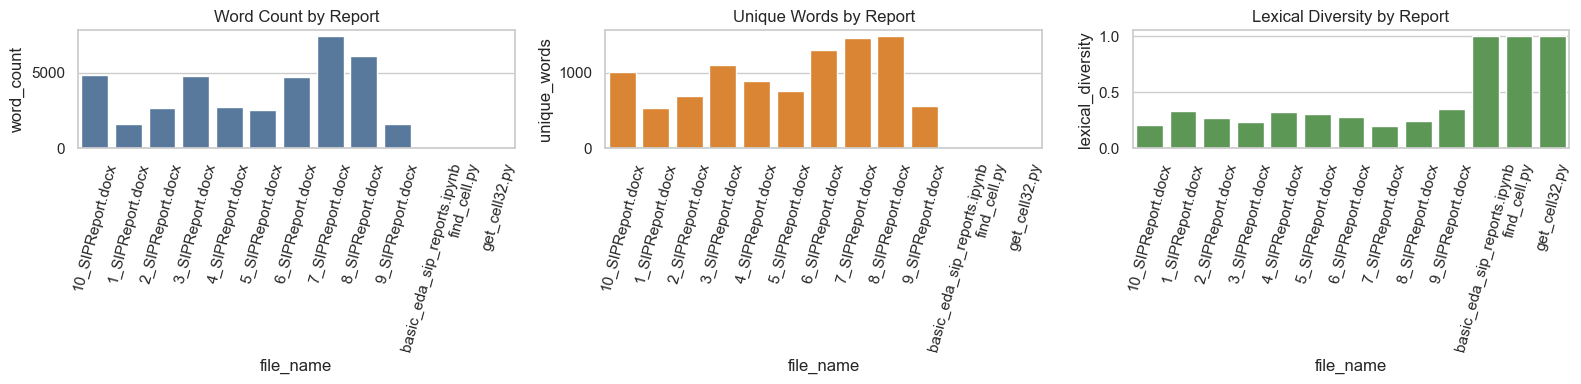

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=df, x='file_name', y='word_count', ax=axes[0], color='#4C78A8')
axes[0].set_title('Word Count by Report')
axes[0].tick_params(axis='x', rotation=75)

sns.barplot(data=df, x='file_name', y='unique_words', ax=axes[1], color='#F58518')
axes[1].set_title('Unique Words by Report')
axes[1].tick_params(axis='x', rotation=75)

sns.barplot(data=df, x='file_name', y='lexical_diversity', ax=axes[2], color='#54A24B')
axes[2].set_title('Lexical Diversity by Report')
axes[2].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

## 7) Corpus Keywords (Simple)

In [77]:
stopwords = {
    'the', 'a', 'an', 'and', 'or', 'to', 'of', 'in', 'for', 'on', 'at', 'is', 'are', 'was', 'were',
    'be', 'been', 'it', 'this', 'that', 'with', 'as', 'by', 'from', 'i', 'we', 'you', 'our', 'your',
    'my', 'their', 'they', 'he', 'she', 'them', 'his', 'her', 'had', 'has', 'have', 'not', 'but'
}

all_words = []
for txt in df['text']:
    tokens = re.findall(r"[A-Za-z0-9']+", txt.lower())
    tokens = [w for w in tokens if len(w) > 2 and w not in stopwords and not w.isdigit()]
    all_words.extend(tokens)

top_terms = Counter(all_words).most_common(20)
top_terms_df = pd.DataFrame(top_terms, columns=['term', 'count'])
top_terms_df

,term,count
0,data,337
1,work,230
2,also,172
3,internship,166
4,how,150
5,will,138
6,more,133
7,can,126
8,company,123
9,department,115


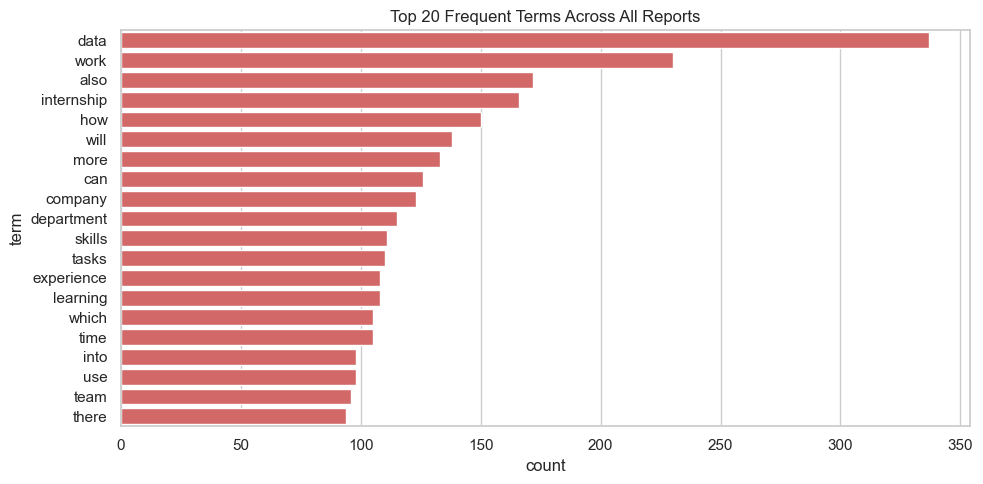

In [78]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_terms_df, x='count', y='term', color='#E45756')
plt.title('Top 20 Frequent Terms Across All Reports')
plt.tight_layout()
plt.show()

## 8) Similarity Between Reports (TF-IDF + Cosine)

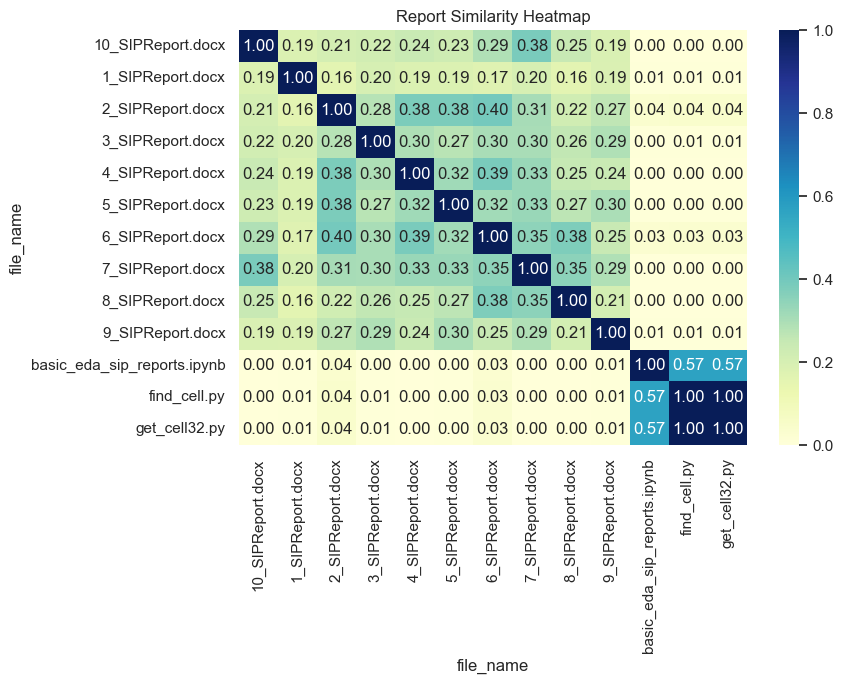

In [79]:
if len(df) >= 2:
    vect = TfidfVectorizer(stop_words='english', min_df=1)
    X = vect.fit_transform(df['text'])
    sim = cosine_similarity(X)

    sim_df = pd.DataFrame(sim, index=df['file_name'], columns=df['file_name'])

    plt.figure(figsize=(9, 7))
    sns.heatmap(sim_df, cmap='YlGnBu', annot=True, fmt='.2f')
    plt.title('Report Similarity Heatmap')
    plt.tight_layout()
    plt.show()

    sim_df
else:
    print('Need at least 2 documents for similarity analysis.')

## 9) Inspect Potential Extraction Issues
Use this to spot files where extracted text looks too short or suspicious.

In [80]:
qa = df[['file_name', 'size_kb', 'char_count', 'word_count', 'line_count']].copy()
qa['chars_per_kb'] = (qa['char_count'] / qa['size_kb'].replace(0, pd.NA)).round(2)
qa.sort_values(['word_count', 'char_count']).reset_index(drop=True)

,file_name,size_kb,char_count,word_count,line_count,chars_per_kb
0,find_cell.py,0.65,28,4,1,43.08
1,get_cell32.py,0.43,28,4,1,65.12
2,basic_eda_sip_reports.ipynb,458.92,31,4,1,0.07
3,9_SIPReport.docx,318.62,9737,1602,95,30.56
4,1_SIPReport.docx,92.01,9053,1632,25,98.39
5,5_SIPReport.docx,572.63,15284,2535,65,26.69
6,2_SIPReport.docx,583.15,14571,2633,47,24.99
7,4_SIPReport.docx,283.91,17094,2741,106,60.21
8,6_SIPReport.docx,42.89,29898,4684,137,697.09
9,3_SIPReport.docx,1238.91,27907,4789,200,22.53


In [81]:
# Preview extracted text for one report (change index as needed)
preview_idx = 0
print('FILE:', df.loc[preview_idx, 'file_name'])
print('-' * 80)
print(df.loc[preview_idx, 'text'][:4000])

FILE: 10_SIPReport.docx
--------------------------------------------------------------------------------
Temasek Polytechnic
School of Informatics and IT
Diploma in Big Data & Analytics
AY 2023/2024 Semester
Student Internship Programme Report
Student’s Declaration of Originality
I hereby declare that the course work(s) submitted by me, is a result of my own effort. I affirm that there is NO plagiarism and copying, either partially or entirely, from someone else’s design and works, without giving proper credit and acknowledgement to the source(s)/author(s).
I am aware that I shall be subjected to disciplinary actions deemed appropriate by the School of Informatics & IT and Temasek Polytechnic if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work.
Introduction
Explain the objectives of the report.
This report is to document about my internship experience. It is about my work environment, organisation structure, nature of business, divers

In [82]:
import numpy as np
from sklearn.decomposition import NMF

try:
    import nltk
    from nltk.tokenize import word_tokenize
except Exception:
    nltk = None
    word_tokenize = None

try:
    from textblob import TextBlob
except Exception:
    TextBlob = None

# Optional visual flair for stakeholders
try:
    from wordcloud import WordCloud
except Exception:
    WordCloud = None

In [83]:
# Install once if needed:
# %pip install nltk textblob wordcloud

## 10) NLP Setup for Advanced Analysis
This section performs tokenisation, keyword extraction, topic modelling, and sentiment analysis to identify:
- tools and technologies used by students
- industry domains and company sectors
- key reflection themes and conclusion patterns

## 11) NLP Preprocessing and Tokenisation

In [84]:
base_stopwords = {
    'the','a','an','and','or','to','of','in','for','on','at','is','are','was','were','be','been','it','this','that',
    'with','as','by','from','i','we','you','our','your','my','their','they','he','she','them','his','her','had',
    'has','have','not','but','if','then','than','so','very','can','could','would','should','during','after','before'
}

def tokenize_text(text: str):
    tokens = re.findall(r"[A-Za-z][A-Za-z0-9+#\-\.]{1,}", (text or '').lower())
    return [t for t in tokens if len(t) > 2 and t not in base_stopwords]

# Analyze only actual report documents
valid_suffixes = {'.docx', '.txt', '.pdf'}
df_nlp = df[df['suffix'].isin(valid_suffixes)][['file_name', 'suffix', 'modified_time', 'text']].copy()
df_nlp['tokens'] = df_nlp['text'].apply(tokenize_text)
df_nlp['token_count'] = df_nlp['tokens'].str.len()
df_nlp['clean_text'] = df_nlp['tokens'].apply(lambda x: ' '.join(x))

df_nlp[['file_name', 'token_count']].sort_values('token_count', ascending=False).head(10)

,file_name,token_count
7,7_SIPReport.docx,4154
8,8_SIPReport.docx,3829
6,6_SIPReport.docx,2841
0,10_SIPReport.docx,2760
3,3_SIPReport.docx,2743
4,4_SIPReport.docx,1617
2,2_SIPReport.docx,1427
5,5_SIPReport.docx,1419
9,9_SIPReport.docx,965
1,1_SIPReport.docx,881


## 12) Keyword Extraction and Classification
This identifies tools/technologies, industry sectors, and reflection themes.

In [85]:
tools_tech_dict = {
    'python':'Programming', 'java':'Programming', 'javascript':'Programming', 'sql':'Database', 'excel':'Analytics',
    'power bi':'BI', 'tableau':'BI', 'matplotlib':'Python Lib', 'seaborn':'Python Lib', 'pandas':'Python Lib',
    'numpy':'Python Lib', 'scikit-learn':'ML', 'tensorflow':'ML', 'pytorch':'ML', 'git':'DevOps',
    'github':'DevOps', 'docker':'DevOps', 'aws':'Cloud', 'azure':'Cloud', 'gcp':'Cloud',
    'mysql':'Database', 'postgresql':'Database', 'mongodb':'Database', 'sap':'Enterprise', 'salesforce':'Enterprise'
}

sector_dict = {
    'healthcare':'Healthcare', 'hospital':'Healthcare', 'medical':'Healthcare',
    'finance':'Finance', 'bank':'Finance', 'insurance':'Finance', 'fintech':'Finance',
    'manufacturing':'Manufacturing', 'factory':'Manufacturing', 'production':'Manufacturing',
    'education':'Education', 'school':'Education', 'university':'Education',
    'logistics':'Logistics', 'supply chain':'Logistics', 'warehouse':'Logistics',
    'retail':'Retail', 'ecommerce':'Retail', 'marketing':'Retail',
    'government':'Public Sector', 'public sector':'Public Sector',
    'consulting':'Consulting', 'engineering':'Engineering', 'telecommunications':'Telecom'
}

theme_dict = {
    'learning':'Learning Growth', 'learned':'Learning Growth', 'improved':'Learning Growth', 'skills':'Learning Growth',
    'communication':'Professional Skills', 'teamwork':'Professional Skills', 'presentation':'Professional Skills',
    'challenge':'Challenges', 'difficult':'Challenges', 'issue':'Challenges', 'problem':'Challenges',
    'mentor':'Support System', 'supervisor':'Support System', 'guidance':'Support System',
    'time management':'Work Habits', 'deadline':'Work Habits', 'responsibility':'Work Habits',
    'confidence':'Personal Development', 'future':'Career Direction', 'career':'Career Direction'
}

def count_dictionary_hits(text: str, key_to_group: dict):
    txt = (text or '').lower()
    counts = Counter()
    for key, grp in key_to_group.items():
        hits = len(re.findall(rf'(?<!\\w){re.escape(key)}(?!\\w)', txt))
        if hits > 0:
            counts[grp] += hits
    return counts

df_nlp['tool_hits'] = df_nlp['text'].apply(lambda t: count_dictionary_hits(t, tools_tech_dict))
df_nlp['sector_hits'] = df_nlp['text'].apply(lambda t: count_dictionary_hits(t, sector_dict))
df_nlp['theme_hits'] = df_nlp['text'].apply(lambda t: count_dictionary_hits(t, theme_dict))

tool_summary = pd.DataFrame(Counter(k for d in df_nlp['tool_hits'] for k in d.elements()).items(), columns=['category','count']).sort_values('count', ascending=False)
sector_summary = pd.DataFrame(Counter(k for d in df_nlp['sector_hits'] for k in d.elements()).items(), columns=['sector','count']).sort_values('count', ascending=False)
theme_summary = pd.DataFrame(Counter(k for d in df_nlp['theme_hits'] for k in d.elements()).items(), columns=['theme','count']).sort_values('count', ascending=False)

print('Top Tools/Technologies Categories')
display(tool_summary.head(15))
print('Top Industry Sectors')
display(sector_summary.head(15))
print('Top Reflection Themes')
display(theme_summary.head(15))

Top Tools/Technologies Categories


,category,count
0,Analytics,69
3,BI,32
2,Programming,17
5,Database,10
1,DevOps,4
4,Enterprise,2
6,Cloud,1


Top Industry Sectors


,sector,count
0,Finance,89
1,Education,63
5,Healthcare,24
3,Logistics,18
4,Retail,13
6,Engineering,6
2,Manufacturing,1
7,Public Sector,1


Top Reflection Themes


,theme,count
0,Learning Growth,272
2,Challenges,141
4,Career Direction,94
1,Professional Skills,63
3,Support System,50
5,Work Habits,18
6,Personal Development,2


## 13) Topic Modelling (NMF)

In [86]:
# Topic modelling with TF-IDF + NMF
n_topics = min(4, max(2, len(df_nlp)))
tfidf_topic = TfidfVectorizer(stop_words='english', max_features=1200, ngram_range=(1, 2), min_df=1)
X_topic = tfidf_topic.fit_transform(df_nlp['clean_text'])

nmf = NMF(n_components=n_topics, random_state=42, init='nndsvda', max_iter=400)
W = nmf.fit_transform(X_topic)
H = nmf.components_
terms = np.array(tfidf_topic.get_feature_names_out())

topic_rows = []
for i, topic_weights in enumerate(H, start=1):
    top_idx = topic_weights.argsort()[::-1][:10]
    top_terms = terms[top_idx]
    topic_rows.append({'topic': f'Topic {i}', 'top_terms': ', '.join(top_terms)})

# Dominant topic per document
df_nlp['dominant_topic'] = [f'Topic {i+1}' for i in W.argmax(axis=1)]
topic_summary = pd.DataFrame(topic_rows)

display(topic_summary)
display(df_nlp[['file_name', 'dominant_topic']].head(20))

,topic,top_terms
0,Topic 1,"data, api, chilli api, chilli, cgh, work, use, time, internship, fig"
1,Topic 2,"work, team, data, learning, financial, chatbot, internship, investment, hsbc, networking"
2,Topic 3,"laptops, hardware, gadgets, defects, checking, skills, laptop, gadgets galaxy, computer hardware, galaxy"
3,Topic 4,"company, sutd, work, data, tasks, survey, freight, dashboards, power, excel"


,file_name,dominant_topic
0,10_SIPReport.docx,Topic 2
1,1_SIPReport.docx,Topic 3
2,2_SIPReport.docx,Topic 1
3,3_SIPReport.docx,Topic 4
4,4_SIPReport.docx,Topic 1
5,5_SIPReport.docx,Topic 1
6,6_SIPReport.docx,Topic 1
7,7_SIPReport.docx,Topic 2
8,8_SIPReport.docx,Topic 2
9,9_SIPReport.docx,Topic 4


## 14) Sentiment Analysis on Reflections and Conclusions

In [87]:
# Sentiment analysis focused on reflection and conclusion wording
positive_lexicon = {
    'improved','improvement','learned','successful','confident','valuable','effective','supportive','helpful',
    'achievement','growth','beneficial','efficient','insightful','productive','motivated'
}
negative_lexicon = {
    'difficult','challenge','challenging','stress','stressed','issue','problem','confusing','overwhelming',
    'frustrating','delay','delayed','limited','insufficient','unclear','error',
    'struggled','struggle','struggling','weakness','weak','failed','failure',
    'difficulty','difficulties','incomplete','unfinished','unable',
    'uncertain','uncertainty','unsure','anxious','anxiety','worried','worry'
}

def simple_sentiment_score(tokens):
    pos = sum(1 for t in tokens if t in positive_lexicon)
    neg = sum(1 for t in tokens if t in negative_lexicon)
    sentiment_hits = pos + neg
    if sentiment_hits == 0:
        return 0.0
    return (pos - neg) / sentiment_hits

df_nlp['sentiment_score'] = df_nlp['tokens'].apply(simple_sentiment_score)

def sentiment_label(s):
    if s > 0.0:
        return 'Positive'
    if s < 0.0:
        return 'Negative'
    return 'Neutral'

df_nlp['sentiment_label'] = df_nlp['sentiment_score'].apply(sentiment_label)

sentiment_summary = (
    df_nlp['sentiment_label']
    .value_counts()
    .reindex(['Positive', 'Neutral', 'Negative'], fill_value=0)
    .rename_axis('sentiment')
    .reset_index(name='count')
)
display(sentiment_summary)
display(df_nlp[['file_name', 'sentiment_score', 'sentiment_label']].sort_values('sentiment_score'))

,sentiment,count
0,Positive,6
1,Neutral,1
2,Negative,3


,file_name,sentiment_score,sentiment_label
1,1_SIPReport.docx,-0.833333,Negative
4,4_SIPReport.docx,-0.181818,Negative
9,9_SIPReport.docx,-0.142857,Negative
2,2_SIPReport.docx,0.000000,Neutral
3,3_SIPReport.docx,0.066667,Positive
0,10_SIPReport.docx,0.111111,Positive
5,5_SIPReport.docx,0.166667,Positive
7,7_SIPReport.docx,0.217391,Positive
8,8_SIPReport.docx,0.435897,Positive
6,6_SIPReport.docx,0.520000,Positive


## 15) Visualisation Dashboard for Stakeholders

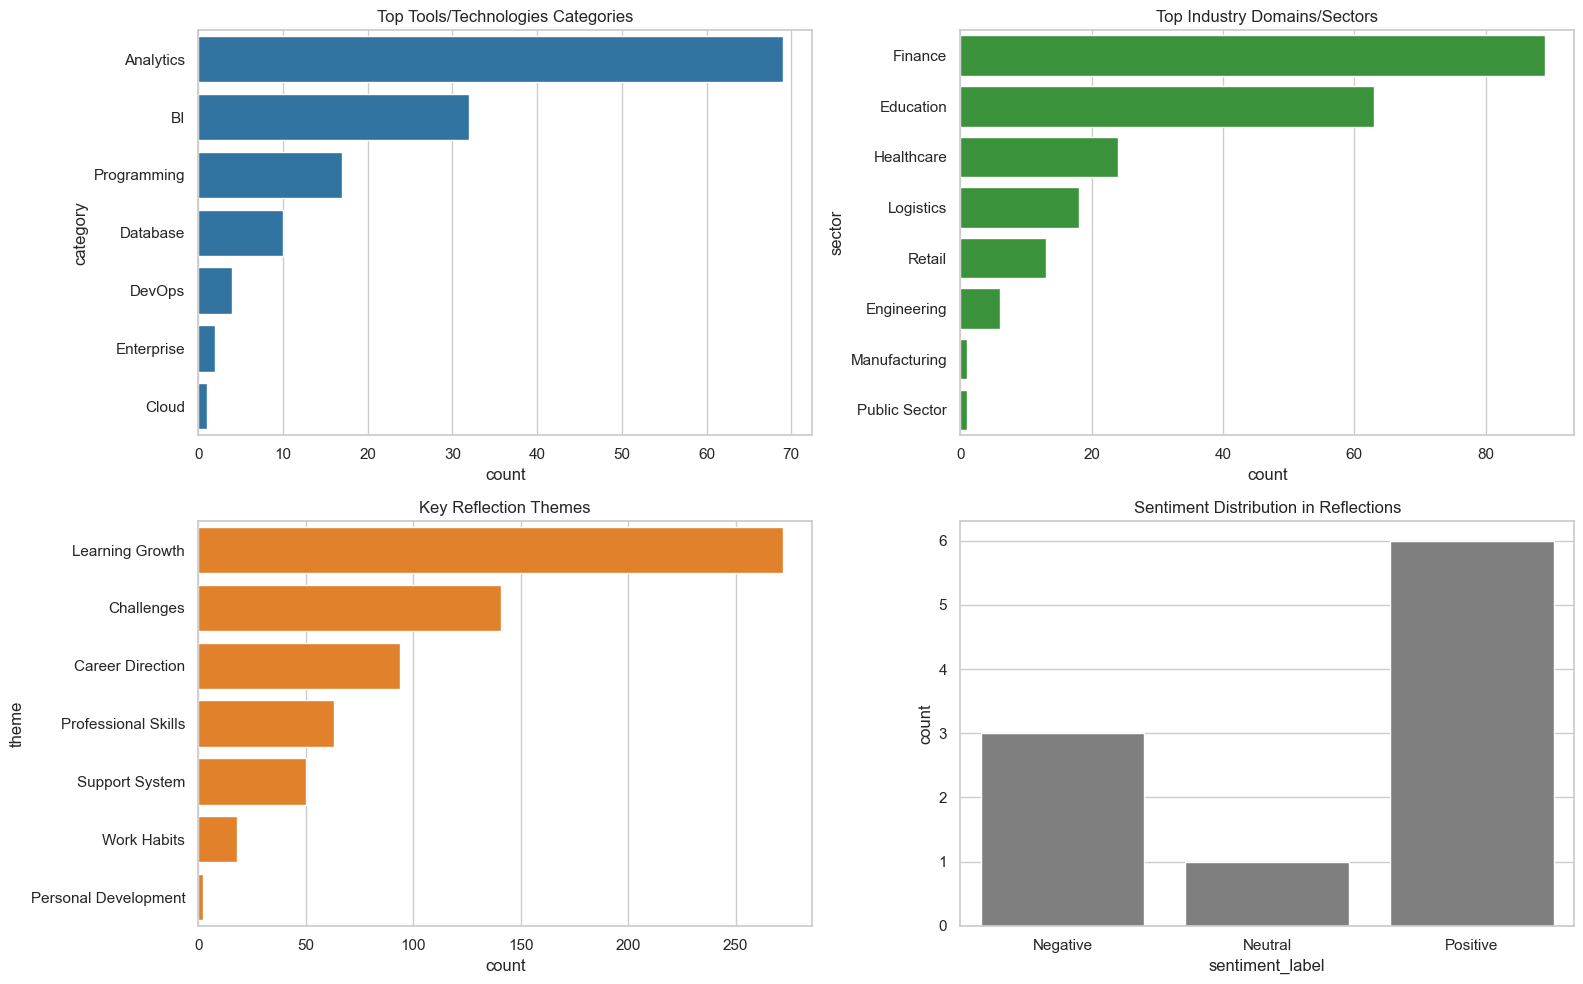

In [88]:
# Stakeholder-friendly dashboard style plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if len(tool_summary) > 0:
    sns.barplot(data=tool_summary.head(10), x='count', y='category', ax=axes[0, 0], color='#1f77b4')
    axes[0, 0].set_title('Top Tools/Technologies Categories')
else:
    axes[0, 0].text(0.5, 0.5, 'No tool signals found', ha='center', va='center')
    axes[0, 0].set_title('Top Tools/Technologies Categories')

if len(sector_summary) > 0:
    sns.barplot(data=sector_summary.head(10), x='count', y='sector', ax=axes[0, 1], color='#2ca02c')
    axes[0, 1].set_title('Top Industry Domains/Sectors')
else:
    axes[0, 1].text(0.5, 0.5, 'No sector signals found', ha='center', va='center')
    axes[0, 1].set_title('Top Industry Domains/Sectors')

if len(theme_summary) > 0:
    sns.barplot(data=theme_summary.head(10), x='count', y='theme', ax=axes[1, 0], color='#ff7f0e')
    axes[1, 0].set_title('Key Reflection Themes')
else:
    axes[1, 0].text(0.5, 0.5, 'No theme signals found', ha='center', va='center')
    axes[1, 0].set_title('Key Reflection Themes')

sns.countplot(data=df_nlp, x='sentiment_label', order=['Negative', 'Neutral', 'Positive'], ax=axes[1, 1], color='#7f7f7f')
axes[1, 1].set_title('Sentiment Distribution in Reflections')

plt.tight_layout()
plt.show()

## 16) Curriculum-Industry Gap Analysis (2nd Task)

In [89]:
# Compare industry-practice terms against curriculum coverage assumptions
curriculum_terms = {
    'python','java','sql','excel','statistics','database','data analysis','machine learning','visualization',
    'communication','teamwork','problem solving','report writing','project management'
}

# Use TF-IDF on full corpus to derive high-signal industry terms
industry_vect = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=250)
industry_X = industry_vect.fit_transform(df_nlp['clean_text'])
industry_scores = np.asarray(industry_X.mean(axis=0)).ravel()
industry_terms = np.array(industry_vect.get_feature_names_out())

rank_idx = industry_scores.argsort()[::-1]
ranked_terms = [industry_terms[i] for i in rank_idx]

high_signal_terms = [t for t in ranked_terms if len(t) > 2][:40]
gap_terms = [t for t in high_signal_terms if t not in curriculum_terms]

gap_df = pd.DataFrame({'industry_high_signal_terms': gap_terms[:20]})

print('Potential curriculum-industry gap terms (top 20):')
display(gap_df)
print(f'Total high-signal terms reviewed: {len(high_signal_terms)}')
print(f'Potential gap terms identified: {len(gap_terms)}')

Potential curriculum-industry gap terms (top 20):


,industry_high_signal_terms
0,data
1,work
2,internship
3,company
4,skills
5,tasks
6,department
7,time
8,use
9,experience


Total high-signal terms reviewed: 40
Potential gap terms identified: 39


## 17) Data-Driven Recommendations (1st Task)

In [90]:
# Actionable recommendations generated from observed signals
recommendations = []

if len(tool_summary) > 0:
    top_tool_groups = ', '.join(tool_summary['category'].head(5).tolist())
    recommendations.append({
        'priority': 'High',
        'objective': 'Align technical curriculum to industry tools',
        'evidence': f'Top tool groups detected: {top_tool_groups}',
        'recommendation': 'Increase hands-on labs and mini-projects using the top detected tool groups.'
    })

if len(sector_summary) > 0:
    top_sectors = ', '.join(sector_summary['sector'].head(5).tolist())
    recommendations.append({
        'priority': 'Medium',
        'objective': 'Strengthen sector readiness',
        'evidence': f'Common internship sectors: {top_sectors}',
        'recommendation': 'Create sector-specific case studies and internship preparation modules.'
    })

neg_rate = (df_nlp['sentiment_label'] == 'Negative').mean() if len(df_nlp) else 0.0
if neg_rate >= 0.25:
    recommendations.append({
        'priority': 'High',
        'objective': 'Improve internship support process',
        'evidence': f'Negative reflection share is {neg_rate:.1%}',
        'recommendation': 'Introduce early check-ins, issue escalation channels, and mentor support tracking.'
    })

if len(gap_terms) > 0:
    recommendations.append({
        'priority': 'High',
        'objective': 'Close curriculum-industry gaps',
        'evidence': f'Identified {len(gap_terms)} potential gap terms from report corpus',
        'recommendation': 'Map uncovered terms to modules and update assessments with industry-aligned tasks.'
    })

if not recommendations:
    recommendations.append({
        'priority': 'Medium',
        'objective': 'Maintain current curriculum quality',
        'evidence': 'No strong adverse signals found in current corpus',
        'recommendation': 'Continue monitoring with larger intake and semester-level trend comparisons.'
    })

recommendations_df = pd.DataFrame(recommendations)
display(recommendations_df)

# Compact management summary report
management_summary = {
    'num_reports': int(len(df_nlp)),
    'top_tool_category': tool_summary.iloc[0]['category'] if len(tool_summary) else 'N/A',
    'top_sector': sector_summary.iloc[0]['sector'] if len(sector_summary) else 'N/A',
    'top_theme': theme_summary.iloc[0]['theme'] if len(theme_summary) else 'N/A',
    'positive_pct': float((df_nlp['sentiment_label'] == 'Positive').mean() * 100) if len(df_nlp) else 0.0,
    'negative_pct': float((df_nlp['sentiment_label'] == 'Negative').mean() * 100) if len(df_nlp) else 0.0,
    'potential_gap_terms': int(len(gap_terms))
}

pd.DataFrame([management_summary])

,priority,objective,evidence,recommendation
0,High,Align technical curriculum to industry tools,"Top tool groups detected: Analytics, BI, Programming, Database, DevOps",Increase hands-on labs and mini-projects using the top detected tool groups.
1,Medium,Strengthen sector readiness,"Common internship sectors: Finance, Education, Healthcare, Logistics, Retail",Create sector-specific case studies and internship preparation modules.
2,High,Improve internship support process,Negative reflection share is 30.0%,"Introduce early check-ins, issue escalation channels, and mentor support tracking."
3,High,Close curriculum-industry gaps,Identified 39 potential gap terms from report corpus,Map uncovered terms to modules and update assessments with industry-aligned tasks.


,num_reports,top_tool_category,top_sector,top_theme,positive_pct,negative_pct,potential_gap_terms
0,10,Analytics,Finance,Learning Growth,60.0,30.0,39
